# GNN time
### Disclaimer: This is a training exercise, I understand that I'm using a model to predict something that is completely fabricated by me


In [2]:
import torch    
import torch.nn as nn
import torch.nn.functional as F
import torch_geometric.transforms as T
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from collections import Counter
from torch_geometric.data import InMemoryDataset, Data
import torch_geometric
from torch_geometric.nn import GATv2Conv
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



In [3]:
# Load the data
nodes_gnn = gpd.read_file('nodes_PC.geojson')
edges_gnn = gpd.read_file('edges_PC.geojson')

Skipping field highway: unsupported OGR type: 5
Skipping field lanes: unsupported OGR type: 5
Skipping field maxspeed: unsupported OGR type: 5
Skipping field name: unsupported OGR type: 5
Skipping field ref: unsupported OGR type: 5
Skipping field width: unsupported OGR type: 5


In [4]:
# Check the data
nodes_gnn.head()

,osmid,y,x,street_count,highway,railway,bc,traffic_lights,geometry
0,92972680,4.989948e+06,552165.187881,3,None,None,0.019900,False,POINT (552165.188 4989947.849)
1,298033861,4.989172e+06,557606.802876,3,motorway_junction,None,0.019896,False,POINT (557606.803 4989172.463)
2,92972786,4.987842e+06,559716.452461,3,motorway_junction,None,0.000000,False,POINT (559716.452 4987842.127)
3,92975190,4.988249e+06,559443.398421,3,None,None,0.001912,False,POINT (559443.398 4988249.205)
4,462186611,4.990028e+06,558166.848537,3,None,None,0.000000,False,POINT (558166.849 4990027.869)


<Axes: >

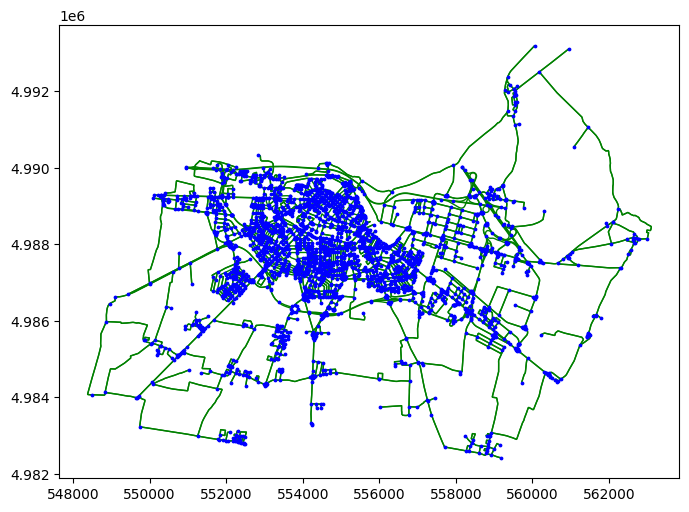

In [5]:
# Check the data
f, ax = plt.subplots(figsize=(8,8))
nodes_gnn.plot(ax=ax, color='blue', markersize=3, zorder=2)
edges_gnn.plot(ax=ax, linewidth= 1, edgecolor= 'green', zorder=1)

In [6]:
# Preprocess the data and prepare the dataset

X = nodes_gnn.drop(columns=['geometry', 'railway', 'highway'])
X = np.array(X.values)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled.shape

(3231, 6)

In [7]:
edges_gnn.columns

Index(['u', 'v', 'key', 'osmid', 'oneway', 'reversed', 'length', 'bridge',
       'speed_kph', 'travel_time', 'junction', 'tunnel', 'access', 'edge_bc',
       'traffic_lights', 'traffic_center', 'traffic_speed', 'traffic_time',
       'geometry'],
      dtype='object')

In [8]:
nodes_gnn['osmid']

0          92972680
1         298033861
2          92972786
3          92975190
4         462186611
           ...     
3226    11902376451
3227    11902376457
3228    11922074615
3229    12029039004
3230    12353647376
Name: osmid, Length: 3231, dtype: int64

In [9]:
Y = edges_gnn['traffic_speed'].values
Y = np.array(Y)
# Prepare edge index 
node_to_id = {}
for i, node in enumerate(nodes_gnn['osmid'].values):
    node_to_id[node] = i

start_node = [node_to_id[i] for i in edges_gnn['u'].values]
end_node = [node_to_id[i] for i in edges_gnn['v'].values]
start = torch.tensor(start_node, dtype=torch.long)
end = torch.tensor(end_node, dtype=torch.long)
edge_index = torch.stack([start, end], dim=0)

In [10]:
# Create dataset for edge regression
class CremonaDataset(InMemoryDataset):
    def __init__(self, edge_index, x, y, pre_transform = None , transform=None):
        super(CremonaDataset, self).__init__('.', transform, None, None)
        
        # Create data object
        data = Data(x=torch.FloatTensor(x), 
                   y=torch.FloatTensor(y), 
                   edge_index=edge_index)
        
        # Set number of nodes and features
        data.num_nodes = x.shape[0]
        data.num_features = x.shape[1]
        data.num_edges = edge_index.shape[1]
        
        # Split data into train/val/test sets (70%/15%/15%)
        np.random.seed(0)
        n_nodes = data.num_nodes
        n_edges = data.num_edges
        indices = np.random.permutation(n_edges)
        #print(n_nodes) #debug
        
        train_idx = indices[:int(0.7 * n_edges)]
        #print(len(train_idx)) #debug
        val_idx = indices[int(0.7 * n_edges):int(0.85 * n_edges)]
        test_idx = indices[int(0.85 * n_edges):]
        
        # Create masks
        train_mask = torch.zeros(n_edges, dtype=torch.bool)
        val_mask = torch.zeros(n_edges, dtype=torch.bool)
        test_mask = torch.zeros(n_edges, dtype=torch.bool)
        
        train_mask[train_idx] = True
        val_mask[val_idx] = True
        test_mask[test_idx] = True
        
        data.train_mask = train_mask    #size is still all nodes but only True for train nodes
        data.val_mask = val_mask
        data.test_mask = test_mask
        
        self.data, self.slices = self.collate([data])
        
        print("Dataset created with {} nodes".format(data.num_nodes), "and {} edges".format(edge_index.shape[1]))
    
    
# Set torch device to cuda if available or else cpu
#device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

dataset = CremonaDataset(edge_index, X_scaled, Y)
data = dataset[0].to(device)

cpu
Dataset created with 3231 nodes and 6930 edges


In [11]:
data.train_mask 

tensor([False,  True,  True,  ..., False,  True,  True])

In [12]:
# Define hyperparameters
HIDDEN_DIM = 64
LR = 0.01


class GATv2(torch.nn.Module):
    def __init__(self, hidden_layer, data, output_dim = 1 , heads=4):
        super(GATv2, self).__init__()
        self.gat1 = GATv2Conv(data.num_features, hidden_layer, heads=heads)
        self.gat2 = GATv2Conv(hidden_layer*heads, hidden_layer, heads=1)
        self.linear = nn.Linear(hidden_layer*2, output_dim)
    
    def forward(self, data):
        # Get node features and edge index
        x, edge_index = data.x, data.edge_index
        
        # First layer
        out= self.gat1(x, edge_index)
        out = F.elu(out)
        out = F.dropout(out, p= 0.5, training=self.training)
        
        # Second layer
        out = self.gat2(out, edge_index)
        
        src, dst = edge_index   # src and dst are the start and end nodes of the edges
        out = torch.concat((out[src], out[dst]), dim=1)  # Concatenate the features of the start and end nodes
        
        # Final layer
        out = self.linear(out)

        return out
    
    def forward_attention(self, data):
        # Get node features and edge index
        x, edge_index = data.x, data.edge_index

        # First layer with attention weights
        out, (edge_index_1, attention_weights_1) = self.gat1(x, edge_index, return_attention_weights=True)
        out = F.elu(out)
        out = F.dropout(out, p=0.5, training=self.training)

        # Second layer with attention weights
        out, (edge_index_2, attention_weights_2) = self.gat2(out, edge_index, return_attention_weights=True)

        # Concatenate the features of the start and end nodes, in order to get the edge features
        # src and dst are the start and end nodes of the edges
        src, dst = edge_index
        out = torch.concat((out[src], out[dst]), dim=1)
        out = self.linear(out)

        # Return output and attention weights if needed
        return out, (edge_index_1, attention_weights_1), (edge_index_2, attention_weights_2)

        


# Initialise GN model instance
model = GATv2(HIDDEN_DIM, data).to(device) 
print(model)

GATv2(
  (gat1): GATv2Conv(6, 64, heads=4)
  (gat2): GATv2Conv(256, 64, heads=1)
  (linear): Linear(in_features=128, out_features=1, bias=True)
)


In [13]:
# Define loss and optimizer
criterion = nn.MSELoss()  # Mean Squared Error for regression
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=20)

# Training function
def train():
    model.train()
    optimizer.zero_grad()
    # Forward pass
    out = model(data)
    # Compute loss (only on training nodes)
    loss = criterion(out[data.train_mask].squeeze(), data.y[data.train_mask]) # squeeze() to remove extra dimension
    # Backward pass
    loss.backward()
    optimizer.step()
    return loss.item()

# Evaluation function
def evaluate(mask):
    model.eval()
    with torch.no_grad():
        out = model(data)
        pred = out[mask].squeeze()
        true = data.y[mask]
        loss = criterion(pred, true)
    return loss.item()

In [46]:
# Training loop
EPOCHS = 1000
best_loss = float('inf')
early_stop_counter = 0
early_stop_patience = 30
train_losses, val_losses = [], []

print(f"Starting training on {device}...")
for epoch in range(1, EPOCHS + 1):
    # Train
    train_loss = train()
    train_losses.append(train_loss)
    
    # Evaluate on validation set
    val_loss = evaluate(data.val_mask)
    val_losses.append(val_loss)
    
    # Adjust learning rate
    scheduler.step(val_loss)
    
    # Early stopping check
    if val_loss < best_loss:
        best_loss = val_loss
        torch.save(model.state_dict(), 'best_CR_gat.pt')
        early_stop_counter = 0
    else:
        early_stop_counter += 1
        
        
    
    # Print progress
    if epoch % 10 == 0:
        test_loss  = evaluate(data.test_mask)
        print(f'Epoch: {epoch:03d}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, '
              f'Test Loss: {test_loss:.4f}, ')
        
    # Check for early stopping
    if early_stop_counter >= early_stop_patience:
        print(f"Early stopping at epoch {epoch}")
        break

Starting training on cpu...
Epoch: 010, Train Loss: 312.8371, Val Loss: 131.4935, Test Loss: 136.8543, 
Epoch: 020, Train Loss: 112.3492, Val Loss: 86.3911, Test Loss: 81.4019, 
Epoch: 030, Train Loss: 101.2230, Val Loss: 99.6272, Test Loss: 100.6094, 
Epoch: 040, Train Loss: 99.6547, Val Loss: 72.9043, Test Loss: 73.9076, 
Epoch: 050, Train Loss: 92.1890, Val Loss: 73.5733, Test Loss: 73.6567, 
Epoch: 060, Train Loss: 93.1166, Val Loss: 76.7171, Test Loss: 77.0506, 
Epoch: 070, Train Loss: 89.9679, Val Loss: 74.7808, Test Loss: 75.4356, 
Epoch: 080, Train Loss: 90.0715, Val Loss: 72.2467, Test Loss: 72.5668, 
Epoch: 090, Train Loss: 88.1821, Val Loss: 71.2880, Test Loss: 71.4806, 
Epoch: 100, Train Loss: 89.8825, Val Loss: 70.7464, Test Loss: 70.6652, 
Epoch: 110, Train Loss: 87.9691, Val Loss: 70.0580, Test Loss: 69.8964, 
Epoch: 120, Train Loss: 87.0776, Val Loss: 69.2086, Test Loss: 69.1976, 
Epoch: 130, Train Loss: 85.5041, Val Loss: 68.3065, Test Loss: 68.2731, 
Epoch: 140, Train

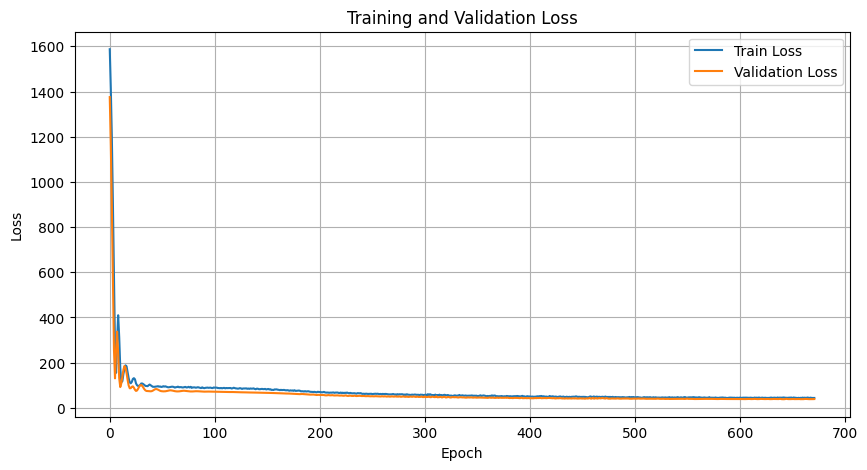

In [47]:
# Plot training and validation loss
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid()

In [14]:
# Load best model for final evaluation
model = GATv2(HIDDEN_DIM, data).to(device)
model.load_state_dict(torch.load('best_CR_gat.pt'))
test_loss = evaluate(data.test_mask)
print(f'Final Test Results - Loss: {test_loss:.4f}')

Final Test Results - Loss: 41.5402


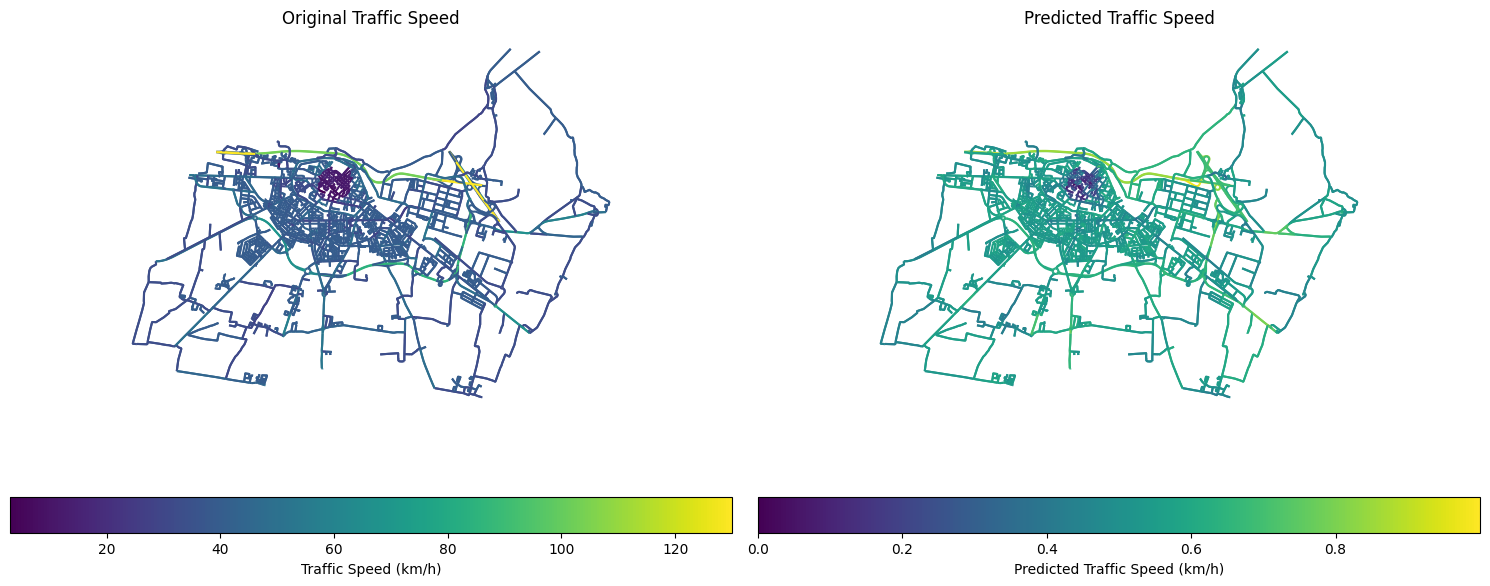

In [15]:
# Generate predictions for all nodes
model.eval()
with torch.no_grad():
    predictions = model(data).squeeze().cpu().numpy()

# Normalize the predictions
scaler = MinMaxScaler()
predictions = scaler.fit_transform(predictions.reshape(-1, 1))
    
# Add predictions back to the geodataframe for visualization
edges_gnn['gat_predictions'] = predictions


#Visualize the predictions

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot the original traffic speed
edges_gnn.plot(column='traffic_speed', ax=ax1, legend=True, cmap='viridis', legend_kwds={
    'label': "Traffic Speed (km/h)",
    'orientation': "horizontal"
})
ax1.set_title('Original Traffic Speed')
ax1.set_axis_off()

# Plot the predicted traffic speed
edges_gnn.plot(column='gat_predictions', ax=ax2, legend=True, cmap='viridis', legend_kwds={
    'label': "Predicted Traffic Speed (km/h)",
    'orientation': "horizontal"
})
ax2.set_title('Predicted Traffic Speed')
ax2.set_axis_off()

plt.tight_layout()
plt.show()

# Next steps I would like to try a Graph Transformer and see how it works
## Instead of a GNN, let's try a Graph Transformer
Let's start with TransformerConv, which should still be very similar to GNNs since its attention mechanism is based on the edges

In [63]:
# Define hyperparameters
HIDDEN_DIM = 64
LR = 0.01
EPOCHS = 1000

class GT(torch.nn.Module):
    def __init__(self, hidden_layer, data, output_dim = 1 , heads=4):
        super(GT, self).__init__()
        self.transf1 = torch_geometric.nn.TransformerConv(data.num_features, hidden_layer, heads=heads, concat=True, dropout=0.5)
        self.layernorm1 = torch.nn.LayerNorm(hidden_layer*heads)
        
        self.transf2 = torch_geometric.nn.TransformerConv(hidden_layer*heads, hidden_layer, heads= heads, concat=False) 
        # No concat here because it is the last layer, which means that it will average the heads
        
        
        self.linear = nn.Linear(hidden_layer*2, output_dim)

    def forward(self, data):
        # Get node features and edge index
        x, edge_index = data.x, data.edge_index
        
        # First layer
        out = self.transf1(x, edge_index)
        out = self.layernorm1(out)
        out = F.relu(out)
        
        # Second layer
        out = self.transf2(out, edge_index) # No Norm and activation function because it is the last layer
        
        
        src, dst = edge_index   # src and dst are the start and end nodes of the edges
        out = torch.concat((out[src], out[dst]), dim=1)  # Concatenate the features of the start and end nodes
        
        # Final layer
        out = self.linear(out)    
        return out
    
    def reset_parameters(self):
        self.transf1.reset_parameters()
        self.transf2.reset_parameters()
        self.layernorm1.reset_parameters()
        
# Initialise GT model instance
model = GT(HIDDEN_DIM, data).to(device)
print(model)

GT(
  (transf1): TransformerConv(6, 64, heads=4)
  (layernorm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  (transf2): TransformerConv(256, 64, heads=4)
  (linear): Linear(in_features=128, out_features=1, bias=True)
)


In [64]:
# Define loss and optimizer
criterion = nn.MSELoss()  # Mean Squared Error for regression
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=20)


def train_tr():
    model.train()
    optimizer.zero_grad()
    # Forward pass
    out = model(data)
    # Compute loss (only on training nodes)
    loss = criterion(out[data.train_mask].squeeze(), data.y[data.train_mask]) # squeeze() to remove extra dimension
    # Backward pass
    loss.backward()
    optimizer.step()
    return loss.item()

def evaluate_tr(mask):
    model.eval()
    with torch.no_grad():
        out = model(data)
        pred = out[mask].squeeze()
        true = data.y[mask]
        loss = criterion(pred, true)
    return loss.item()

In [65]:
out = model(data)
out[data.train_mask].squeeze()

tensor([ 0.0917,  0.0957,  0.0851,  ..., -0.2275, -0.3068, -0.4832],
       grad_fn=<SqueezeBackward0>)

In [66]:
# Training loop
best_loss = float('inf')
early_stop_counter = 0
early_stop_patience = 30
train_losses, val_losses = [], []


print(f"Starting training on {device}...")
model.reset_parameters()
for epoch in range(1, EPOCHS + 1):
    # Train
    train_loss = train_tr()
    train_losses.append(train_loss)
    
    # Evaluate on validation set
    val_loss = evaluate_tr(data.val_mask)
    val_losses.append(val_loss)
    
    # Adjust learning rate
    scheduler.step(val_loss)
    
    # Early stopping check
    if val_loss < best_loss:
        best_loss = val_loss
        torch.save(model.state_dict(), 'best_CR_gt.pt')
        early_stop_counter = 0
    else:
        early_stop_counter += 1
        
        
    
    # Print progress
    if epoch % 10 == 0:
        test_loss  = evaluate_tr(data.test_mask)
        print(f'Epoch: {epoch:03d}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, '
              f'Test Loss: {test_loss:.4f}, ')
        
    # Check for early stopping
    if early_stop_counter >= early_stop_patience:
        print(f"Early stopping at epoch {epoch}")
        break

Starting training on cpu...
Epoch: 010, Train Loss: 171.6058, Val Loss: 206.1365, Test Loss: 208.7408, 
Epoch: 020, Train Loss: 131.4748, Val Loss: 95.5809, Test Loss: 94.3198, 
Epoch: 030, Train Loss: 80.8806, Val Loss: 81.4944, Test Loss: 80.6298, 
Epoch: 040, Train Loss: 86.9214, Val Loss: 64.5229, Test Loss: 64.5055, 
Epoch: 050, Train Loss: 75.6692, Val Loss: 61.2707, Test Loss: 61.4735, 
Epoch: 060, Train Loss: 73.4667, Val Loss: 61.9678, Test Loss: 62.2679, 
Epoch: 070, Train Loss: 71.6974, Val Loss: 61.2486, Test Loss: 61.7189, 
Epoch: 080, Train Loss: 69.0332, Val Loss: 59.2747, Test Loss: 59.7993, 
Epoch: 090, Train Loss: 68.1639, Val Loss: 57.7137, Test Loss: 58.4620, 
Epoch: 100, Train Loss: 65.6619, Val Loss: 56.5342, Test Loss: 57.5163, 
Epoch: 110, Train Loss: 63.7141, Val Loss: 54.6178, Test Loss: 55.9973, 
Epoch: 120, Train Loss: 62.4560, Val Loss: 53.1750, Test Loss: 54.7672, 
Epoch: 130, Train Loss: 60.9558, Val Loss: 51.9352, Test Loss: 53.7469, 
Epoch: 140, Train L

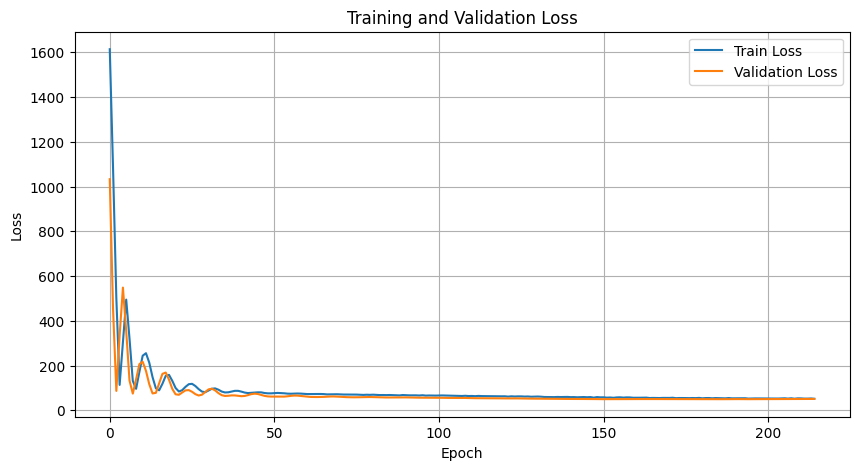

In [67]:
# Plot training and validation loss
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid()


In [68]:
# Load best model for final evaluation
model.load_state_dict(torch.load('best_CR_gt.pt'))
test_loss = evaluate_tr(data.test_mask)
print(f'Final Test Results - Loss: {test_loss:.4f}')

Final Test Results - Loss: 52.3714


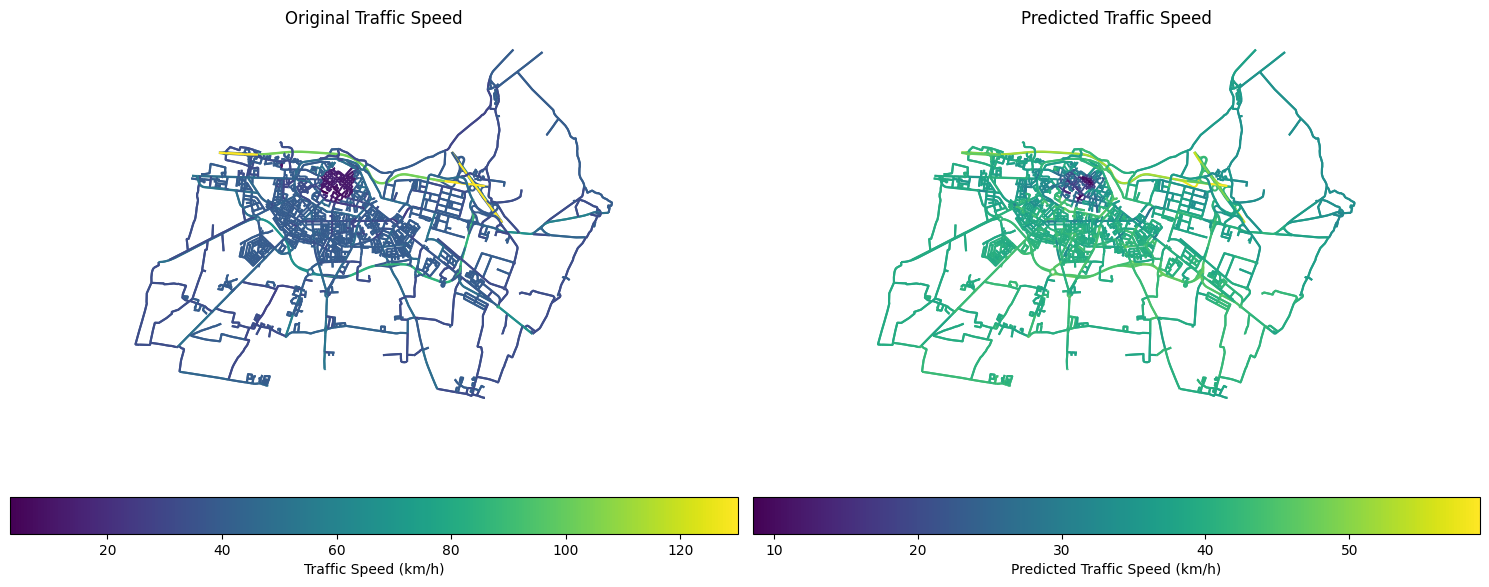

In [69]:
# Generate predictions for all nodes
model.eval()
with torch.no_grad():
    predictions = model(data).squeeze().cpu().numpy()
# Add predictions back to the geodataframe for visualization
edges_gnn['predictions_tr'] = predictions
#Visualize the predictions
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
# Plot the original traffic speed
edges_gnn.plot(column='traffic_speed', ax=ax1, legend=True, cmap='viridis', legend_kwds={
    'label': "Traffic Speed (km/h)",
    'orientation': "horizontal"
})
ax1.set_title('Original Traffic Speed')
ax1.set_axis_off()
# Plot the predicted traffic speed
edges_gnn.plot(column='predictions_tr', ax=ax2, legend=True, cmap='viridis', legend_kwds={
    'label': "Predicted Traffic Speed (km/h)",
    'orientation': "horizontal"
})
ax2.set_title('Predicted Traffic Speed')
ax2.set_axis_off()
plt.tight_layout()
plt.show()

Skipping field highway: unsupported OGR type: 5
Skipping field lanes: unsupported OGR type: 5
Skipping field name: unsupported OGR type: 5
Skipping field maxspeed: unsupported OGR type: 5
Skipping field bridge: unsupported OGR type: 5


<Axes: >

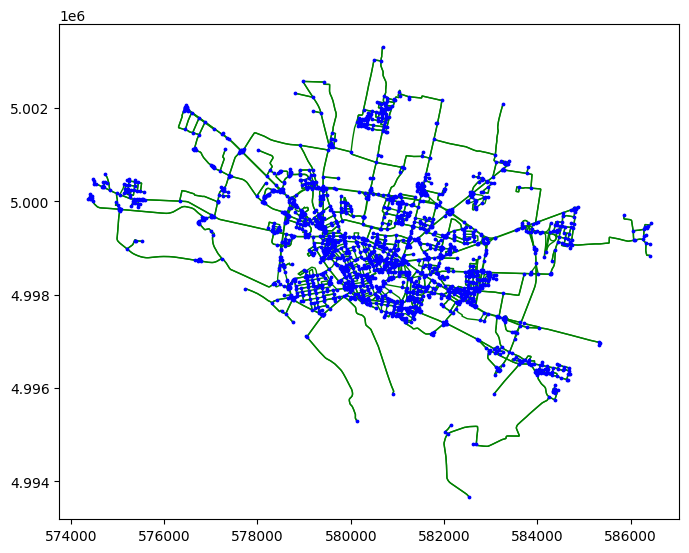

In [70]:
# Load new data
nodes_gnn2 = gpd.read_file('nodes_CR.geojson')
edges_gnn2 = gpd.read_file('edges_CR.geojson')
#plot
f, ax = plt.subplots(figsize=(8,8))
nodes_gnn2.plot(ax=ax, color='blue', markersize=3, zorder=2)
edges_gnn2.plot(ax=ax, linewidth= 1, edgecolor= 'green', zorder=1)


In [71]:
# Check the data
nodes_gnn2.head()

,osmid,y,x,street_count,highway,junction,bc,traffic_lights,geometry
0,249617125,5.000033e+06,578681.931488,3,None,None,0.221561,False,POINT (578681.931 5000032.907)
1,302402633,4.999980e+06,578679.421611,3,None,None,0.221585,False,POINT (578679.422 4999980.367)
2,249617128,4.999968e+06,578742.690104,3,None,None,0.231506,False,POINT (578742.69 4999967.629)
3,302402587,4.999994e+06,578765.527141,3,None,None,0.246801,False,POINT (578765.527 4999993.867)
4,302415503,4.999956e+06,578784.130629,3,None,None,0.288959,False,POINT (578784.131 4999955.721)


In [72]:
# Preprocess the data and prepare the dataset
X2 = nodes_gnn2.drop(columns=['geometry', 'junction', 'highway'])
X2 = np.array(X2.values)
scaler = StandardScaler()
X2_scaled = scaler.fit_transform(X2)
X2_scaled.shape

(2280, 6)

In [73]:
# Prepare edge index
node_to_id2 = {}
for i, node in enumerate(nodes_gnn2['osmid'].values):
    node_to_id2[node] = i
start_node_pc = [node_to_id2[i] for i in edges_gnn2['u'].values]
end_node_pc = [node_to_id2[i] for i in edges_gnn2['v'].values]
start_pc = torch.tensor(start_node_pc, dtype=torch.long)
end_pc = torch.tensor(end_node_pc, dtype=torch.long)
edge_index2 = torch.stack([start_pc, end_pc], dim=0)

Y2 = edges_gnn2['traffic_speed'].values
Y2 = np.array(Y2)

In [74]:
# Create dataset for edge regression
data2 = CremonaDataset(edge_index2, X2_scaled, Y2)

Dataset created with 2280 nodes and 4786 edges


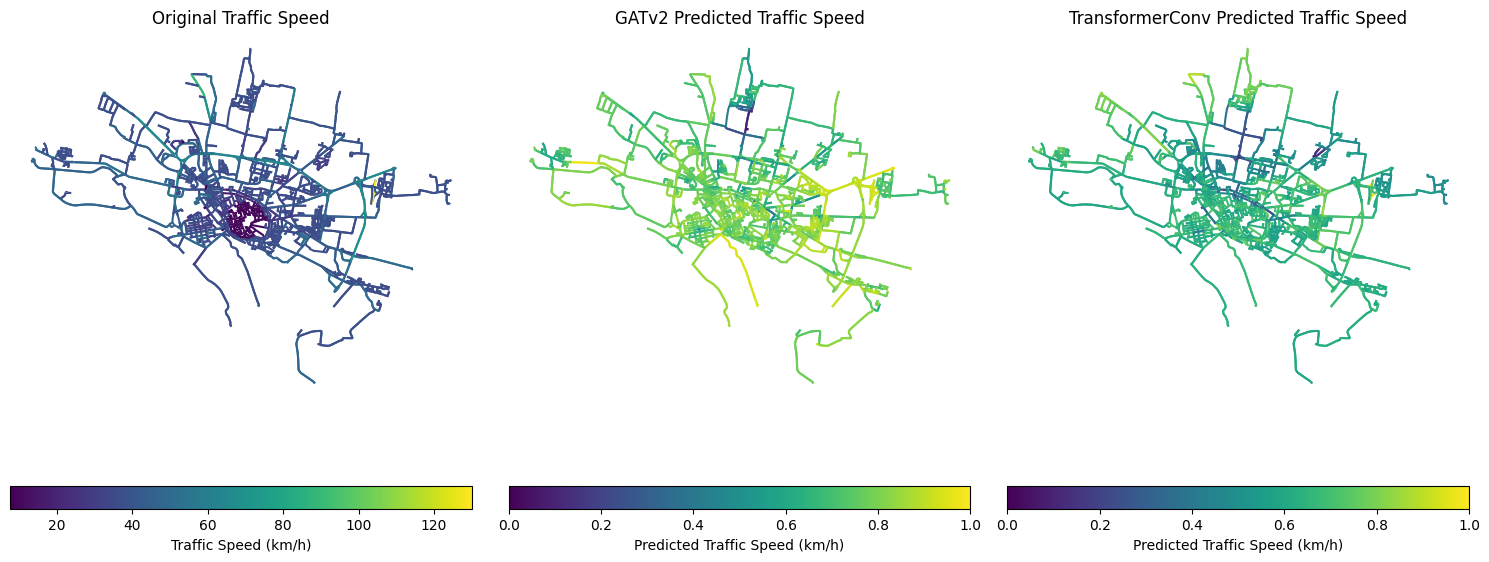

In [75]:
# Compare the models:
gat_model = GATv2(HIDDEN_DIM, data2[0]).to(device)
gat_model.load_state_dict(torch.load('best_CR_gat.pt'))
gt_model = GT(HIDDEN_DIM, data2[0]).to(device)
gt_model.load_state_dict(torch.load('best_CR_gt.pt'))

gat_model.eval()
gt_model.eval()
with torch.no_grad():
    gat_predictions = gat_model(data2[0]).squeeze().cpu().numpy()
    gt_predictions = gt_model(data2[0]).squeeze().cpu().numpy()
    
# Normalize the predictions
scaler = MinMaxScaler()
gat_predictions = scaler.fit_transform(gat_predictions.reshape(-1, 1))
gt_predictions = scaler.fit_transform(gt_predictions.reshape(-1, 1))

# Add predictions back to the geodataframe for visualization
edges_gnn2['gat_predictions'] = gat_predictions
edges_gnn2['gt_predictions'] = gt_predictions

# Visualize the predictions
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 6))
# Plot the original traffic speed
edges_gnn2.plot(column='traffic_speed', ax=ax1, legend=True, cmap='viridis', legend_kwds={
    'label': "Traffic Speed (km/h)",
    'orientation': "horizontal"
})
ax1.set_title('Original Traffic Speed')
ax1.set_axis_off()
# Plot the GAT predictions
edges_gnn2.plot(column='gat_predictions', ax=ax2, legend=True, cmap='viridis', legend_kwds={
    'label': "Predicted Traffic Speed (km/h)",
    'orientation': "horizontal"
})
ax2.set_title('GATv2 Predicted Traffic Speed')
ax2.set_axis_off()
# Plot the GT predictions
edges_gnn2.plot(column='gt_predictions', ax=ax3, legend=True, cmap='viridis', legend_kwds={
    'label': "Predicted Traffic Speed (km/h)",
    'orientation': "horizontal"
})
ax3.set_title('TransformerConv Predicted Traffic Speed')
ax3.set_axis_off()
plt.tight_layout()
plt.show()

## Don't stop me now, I'm having such a good time 
### I want to try a proper transformer model, like the GPS 

In [16]:
import argparse
import os.path as osp
from typing import Any, Dict, Optional

import torch
from torch.nn import (
    BatchNorm1d,
    Embedding,
    Linear,
    ModuleList,
    ReLU,
    Sequential,
)
from torch.optim.lr_scheduler import ReduceLROnPlateau

import torch_geometric.transforms as T
from torch_geometric.datasets import ZINC
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GINConv, GPSConv, global_add_pool
from torch_geometric.nn.attention import PerformerAttention

In [17]:
# Preprocess the data and prepare the dataset
transform = T.AddRandomWalkPE( walk_length= 20, attr_name= 'pe')
transform2 = T.AddLaplacianEigenvectorPE(k = 20, attr_name= 'pe')
data = Data(x = torch.FloatTensor(X_scaled), y = torch.FloatTensor(Y), edge_index = edge_index )
data = transform2(data)

data.num_edges

6930

In [18]:
 # Split data into train/val/test sets (70%/15%/15%)
np.random.seed(10)
        
n_edges = data.num_edges
indices = np.random.permutation(n_edges)
        
train_idx = indices[:int(0.7 * n_edges)]
print(len(train_idx)) #debug
val_idx = indices[int(0.7 * n_edges):int(0.85 * n_edges)]
print(len(val_idx)) #debug
test_idx = indices[int(0.85 * n_edges):]
print(len(test_idx)) #debug
        
# Create masks
train_mask = torch.zeros(n_edges, dtype=torch.bool)
val_mask = torch.zeros(n_edges, dtype=torch.bool)
test_mask = torch.zeros(n_edges, dtype=torch.bool)
    
train_mask[train_idx] = True
val_mask[val_idx] = True
test_mask[test_idx] = True
        
data.train_mask = train_mask    #size is still all nodes but only True for train nodes
data.val_mask = val_mask
data.test_mask = test_mask

data.to(device)

4851
1039
1040


Data(x=[3231, 6], edge_index=[2, 6930], y=[6930], pe=[3231, 20], train_mask=[6930], val_mask=[6930], test_mask=[6930])

In [19]:
class RedrawProjection:
    def __init__(self, model: torch.nn.Module,
                redraw_interval: Optional[int] = None):
        self.model = model
        self.redraw_interval = redraw_interval
        self.num_last_redraw = 0

    def redraw_projections(self):
        if not self.model.training or self.redraw_interval is None:
            return
        if self.num_last_redraw >= self.redraw_interval:
            fast_attentions = [
                module for module in self.model.modules()
                if isinstance(module, PerformerAttention)
            ]
            for fast_attention in fast_attentions:
                fast_attention.redraw_projection_matrix()
            self.num_last_redraw = 0
            return
        self.num_last_redraw += 1



In [20]:
class GPS(torch.nn.Module):
    def __init__(self, channels: int, pe_dim: int, num_layers: int,
                 attn_type: str = 'performer', dropout: float = 0.0):
        super().__init__()

        self.node_emb = Linear(data.x.shape[1], channels - pe_dim)
        self.pe_lin = Linear(20, pe_dim)
        self.pe_norm = BatchNorm1d(20)

        self.convs = ModuleList()
        for _ in range(num_layers):
            nn = Sequential(
                Linear(channels, channels),
                ReLU(),
                Linear(channels, channels),
            )
            conv = GPSConv(channels, GINConv(nn), heads=4,
                           attn_type=attn_type, dropout=dropout)
            self.convs.append(conv)

        self.mlp = Sequential(
            Linear(2* channels, channels),
            ReLU(),
            Linear(channels, 1)
            
        )
        self.redraw_projection = RedrawProjection(
            self.convs,
            redraw_interval=1000 if attn_type == 'performer' else None)

    def forward(self, x, pe, edge_index):
        x_pe = self.pe_norm(pe)
        x = torch.cat((self.node_emb(x), self.pe_lin(x_pe)), 1)
        

        for conv in self.convs:
            x = conv(x, edge_index)
        
        # Edge-level prediction
        src, dst = edge_index
        x = torch.cat((x[src], x[dst]), dim=1)
        
        x = self.mlp(x)
        return x

In [21]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = GPS(channels= 64, pe_dim=8, num_layers=2, attn_type= 'performer',
            dropout= 0.5).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=20,
                              min_lr=0.00001)

In [22]:
model

GPS(
  (node_emb): Linear(in_features=6, out_features=56, bias=True)
  (pe_lin): Linear(in_features=20, out_features=8, bias=True)
  (pe_norm): BatchNorm1d(20, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (convs): ModuleList(
    (0-1): 2 x GPSConv(64, conv=GINConv(nn=Sequential(
      (0): Linear(in_features=64, out_features=64, bias=True)
      (1): ReLU()
      (2): Linear(in_features=64, out_features=64, bias=True)
    )), heads=4, attn_type=performer)
  )
  (mlp): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=1, bias=True)
  )
)

In [23]:
criterion = nn.MSELoss()
def train(data):
    model.train()
    optimizer.zero_grad()
    model.redraw_projection.redraw_projections()
    out = model(data.x, data.pe, data.edge_index)
    pred = out[data.train_mask].squeeze()
    loss = criterion(out[data.train_mask].squeeze(), data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()

def evaluate(data, mask):
    model.eval()
    with torch.no_grad():
        out = model(data.x, data.pe, data.edge_index)
        pred = out[mask].squeeze()
        true = data.y[mask]
        loss = criterion(pred, true)
    return loss.item()

In [24]:
out = model(data.x, data.pe, data.edge_index)
out[data.val_mask].squeeze().size()

torch.Size([1039])

In [69]:
# Training loop
EPOCHS = 500

best_loss = float('inf')
early_stop_counter = 0
early_stop_patience = 30
train_losses, val_losses = [], []

print(f"Starting training on {device}...")

for epoch in range(1, EPOCHS + 1):
    # Train
    train_loss = train(data)
    train_losses.append(train_loss)
    
    # Evaluate on validation set
    val_loss = evaluate(data, data.val_mask)
    val_losses.append(val_loss)
    
    # Adjust learning rate
    scheduler.step(val_loss)
    
    # Early stopping check
    if val_loss < best_loss:
        best_loss = val_loss
        torch.save(model.state_dict(), 'best_CR_gps.pt')
        early_stop_counter = 0
    else:
        early_stop_counter += 1
        
        
    
    # Print progress
    if epoch % 10 == 0:
        test_loss  = evaluate(data, data.test_mask)
        print(f'Epoch: {epoch:03d}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, '
              f'Test Loss: {test_loss:.4f}, ')
        
    # Check for early stopping
    if early_stop_counter >= early_stop_patience:
        print(f"Early stopping at epoch {epoch}")
        break

Starting training on cpu...
Epoch: 010, Train Loss: 1512.4781, Val Loss: 1479.5979, Test Loss: 1493.2610, 
Epoch: 020, Train Loss: 1389.2771, Val Loss: 1161.3701, Test Loss: 1179.2401, 
Epoch: 030, Train Loss: 1210.8979, Val Loss: 1074.1273, Test Loss: 1095.7194, 
Epoch: 040, Train Loss: 985.8654, Val Loss: 1022.4139, Test Loss: 1041.9688, 
Epoch: 050, Train Loss: 737.6183, Val Loss: 843.5081, Test Loss: 869.5080, 
Epoch: 060, Train Loss: 498.1805, Val Loss: 611.9794, Test Loss: 641.8725, 
Epoch: 070, Train Loss: 304.2120, Val Loss: 429.2202, Test Loss: 454.5835, 
Epoch: 080, Train Loss: 179.0885, Val Loss: 332.1128, Test Loss: 359.6346, 
Epoch: 090, Train Loss: 113.1240, Val Loss: 272.7330, Test Loss: 303.4732, 
Epoch: 100, Train Loss: 85.3134, Val Loss: 158.3490, Test Loss: 176.3554, 
Epoch: 110, Train Loss: 75.7762, Val Loss: 109.4345, Test Loss: 126.2962, 
Epoch: 120, Train Loss: 72.2691, Val Loss: 97.3804, Test Loss: 114.9807, 
Epoch: 130, Train Loss: 68.1901, Val Loss: 107.6912, 

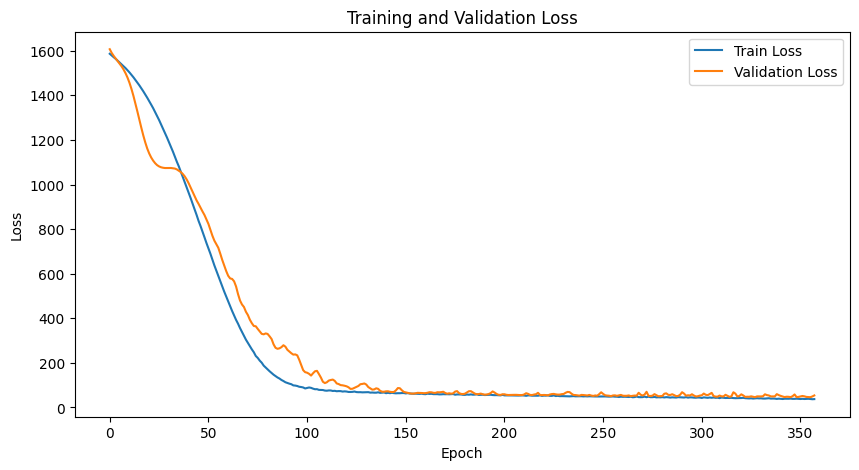

In [70]:
# Plot training and validation loss
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

In [25]:
# Load best model for final evaluation
model.load_state_dict(torch.load('best_CR_gps.pt'))
test_loss = evaluate(data, data.test_mask)
print(f'Final Test Results - Loss: {test_loss:.4f}')

Final Test Results - Loss: 172.8042


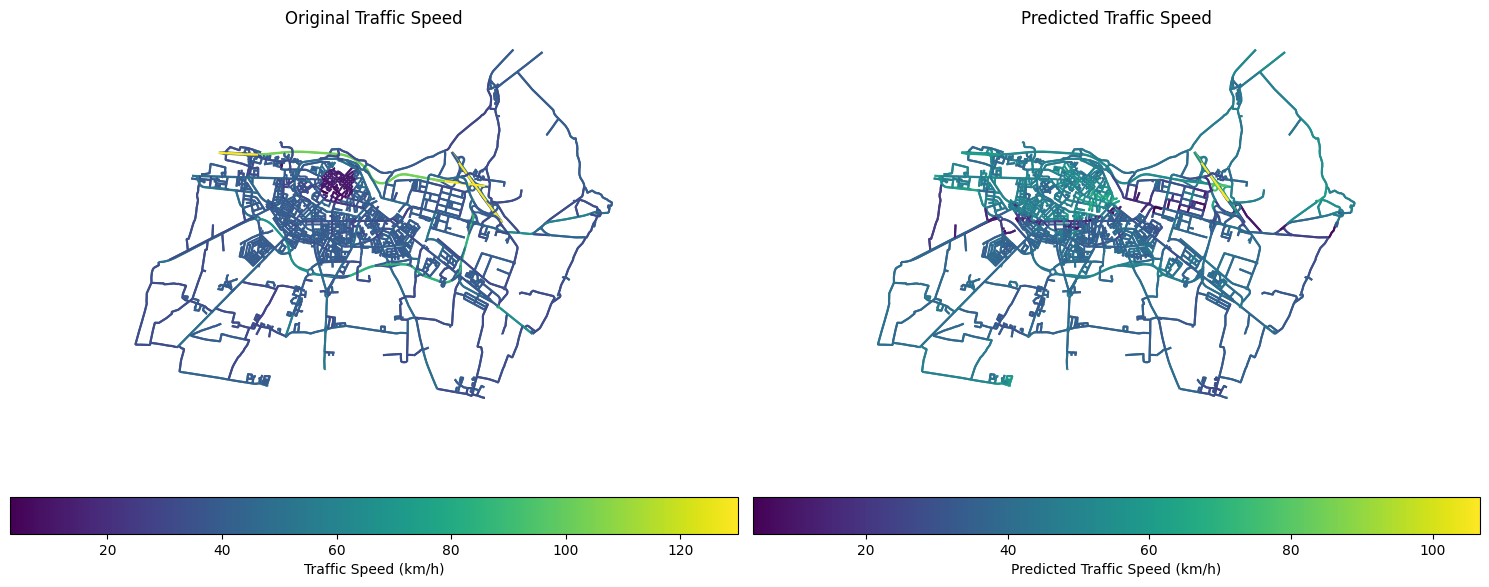

In [26]:
# Generate predictions for all nodes
model.eval()
with torch.no_grad():
    predictions = model(data.x, data.pe, data.edge_index).squeeze().cpu().numpy()
# Add predictions back to the geodataframe for visualization
edges_gnn['gps_predictions'] = predictions
#Visualize the predictions
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
# Plot the original traffic speed
edges_gnn.plot(column='traffic_speed', ax=ax1, legend=True, cmap='viridis', legend_kwds={
    'label': "Traffic Speed (km/h)",
    'orientation': "horizontal"
})
ax1.set_title('Original Traffic Speed')
ax1.set_axis_off()
# Plot the predicted traffic speed
edges_gnn.plot(column='gps_predictions', ax=ax2, legend=True, cmap='viridis', legend_kwds={
    'label': "Predicted Traffic Speed (km/h)",
    'orientation': "horizontal"
})
ax2.set_title('Predicted Traffic Speed')
ax2.set_axis_off()
plt.tight_layout()
plt.show()

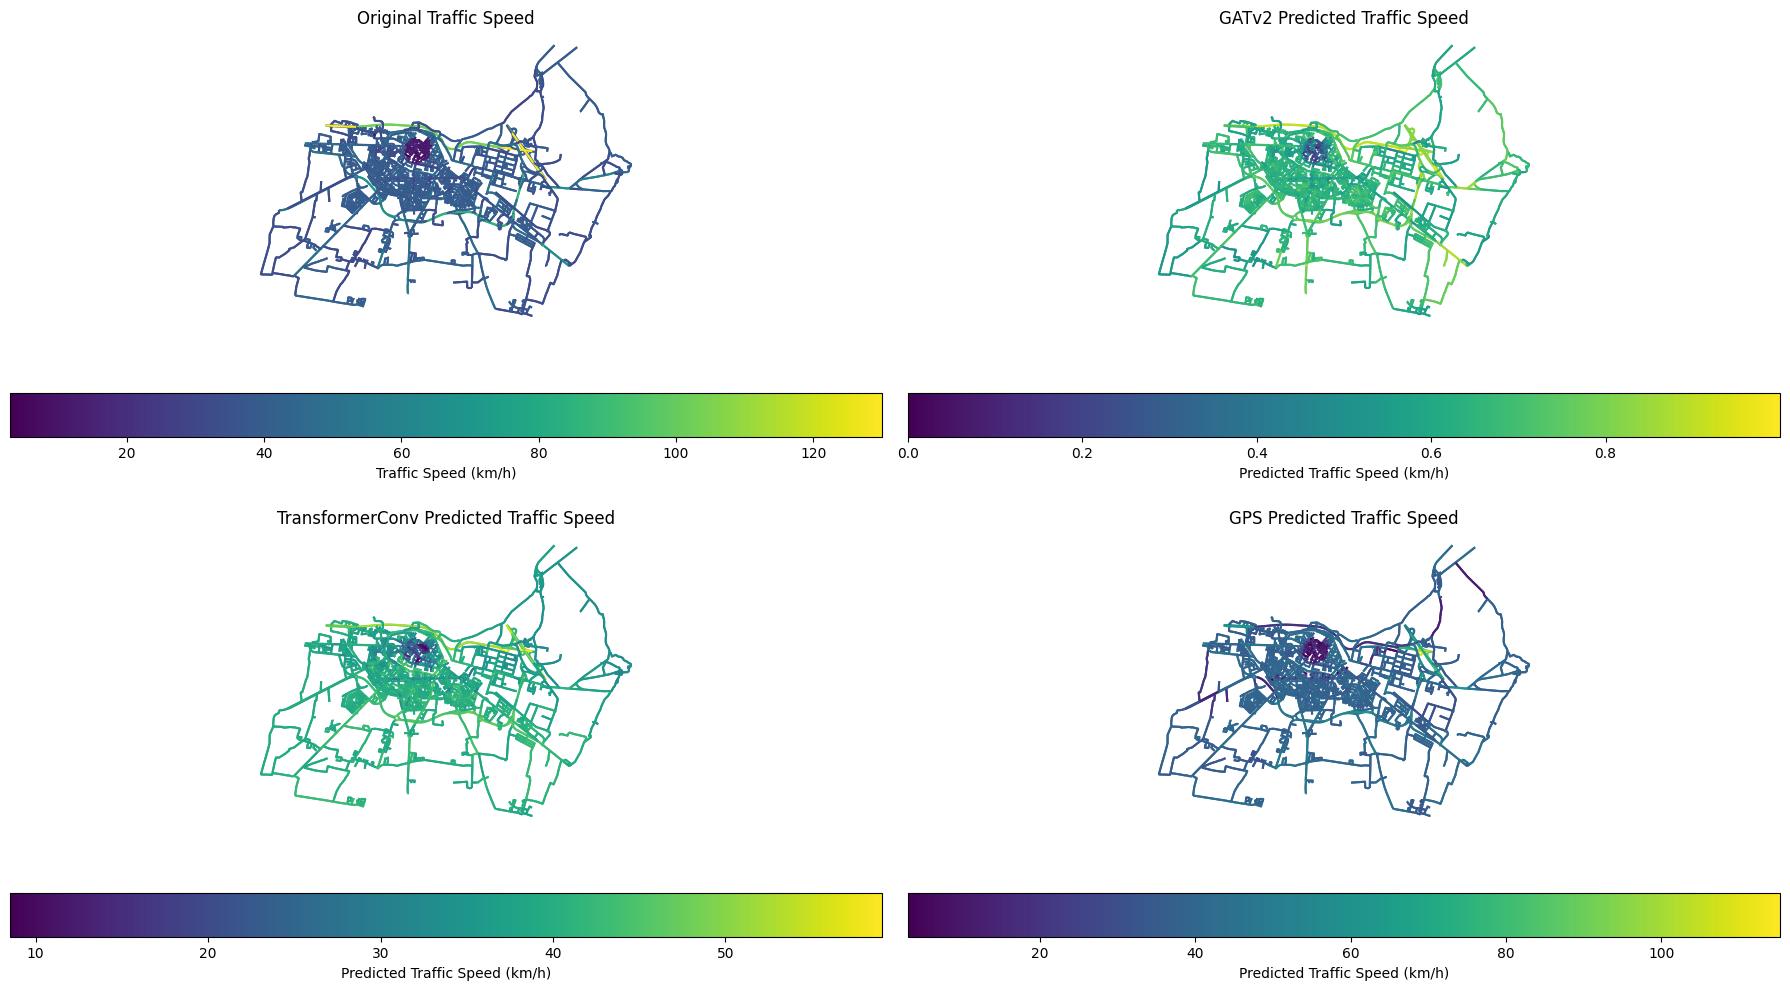

In [89]:
# Compare the three models with the ground truth
fig, axs = plt.subplots(2, 2, figsize=(18, 10))
ax1, ax2, ax3, ax4 = axs.flatten()
# Plot the original traffic speed
edges_gnn.plot(column='traffic_speed', ax=ax1, legend=True, cmap='viridis', legend_kwds={
    'label': "Traffic Speed (km/h)",
    'orientation': "horizontal"
})
ax1.set_title('Original Traffic Speed')
ax1.set_axis_off()
# Plot the GAT predictions
edges_gnn.plot(column='gat_predictions', ax=ax2, legend=True, cmap='viridis', legend_kwds={
    'label': "Predicted Traffic Speed (km/h)",
    'orientation': "horizontal"
})
ax2.set_title('GATv2 Predicted Traffic Speed')
ax2.set_axis_off()
# Plot the GT predictions
edges_gnn.plot(column='predictions_tr', ax=ax3, legend=True, cmap='viridis', legend_kwds={
    'label': "Predicted Traffic Speed (km/h)",
    'orientation': "horizontal"
})
ax3.set_title('TransformerConv Predicted Traffic Speed')
ax3.set_axis_off()
# Plot the GPS predictions
edges_gnn.plot(column='gps_predictions', ax=ax4, legend=True, cmap='viridis', legend_kwds={
    'label': "Predicted Traffic Speed (km/h)",
    'orientation': "horizontal"
})
ax4.set_title('GPS Predicted Traffic Speed')
ax4.set_axis_off()
plt.tight_layout()
plt.savefig('Cremona_GNNs.png', dpi=600, bbox_inches='tight')
plt.show()



In [90]:
data2 = Data(x = torch.FloatTensor(X2_scaled), y = torch.FloatTensor(Y2), edge_index = edge_index2 )
data2 = transform2(data2)
#set seed
torch.manual_seed(0)
idxs = torch.randperm(data2.num_edges)
ft_idx = idxs[:int(0.3 * data2.num_edges)]
ft_val_idx = idxs[int(0.3 * data2.num_edges):int(0.4 * data2.num_edges)]

data2.train_mask = torch.zeros(data2.num_edges, dtype=torch.bool)
data2.train_mask[ft_idx] = True
data2.val_mask = torch.zeros(data2.num_edges, dtype=torch.bool)
data2.val_mask[ft_val_idx] = True





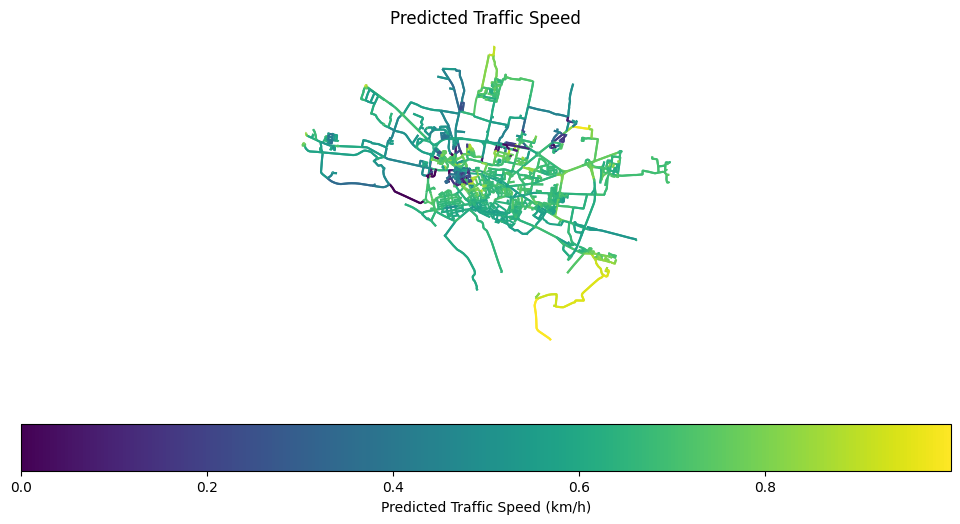

In [91]:
# predictions for the new data
model.eval()
with torch.no_grad():
    predictions_pc = model(data2.x, data2.pe, data2.edge_index).squeeze().cpu().numpy()
    
# Normalize the predictions
scaler = MinMaxScaler()
predictions_pc = scaler.fit_transform(predictions_pc.reshape(-1, 1))
# Add predictions back to the geodataframe for visualization
edges_gnn2['gps_predictions'] = predictions_pc
#Visualize the predictions
fig, ax = plt.subplots(1, 1, figsize=(12, 6))
# Plot the predicted traffic speed
edges_gnn2.plot(column='gps_predictions', ax=ax, legend=True, cmap='viridis', legend_kwds={
    'label': "Predicted Traffic Speed (km/h)",
    'orientation': "horizontal"
})
ax.set_title('Predicted Traffic Speed')
ax.set_axis_off()

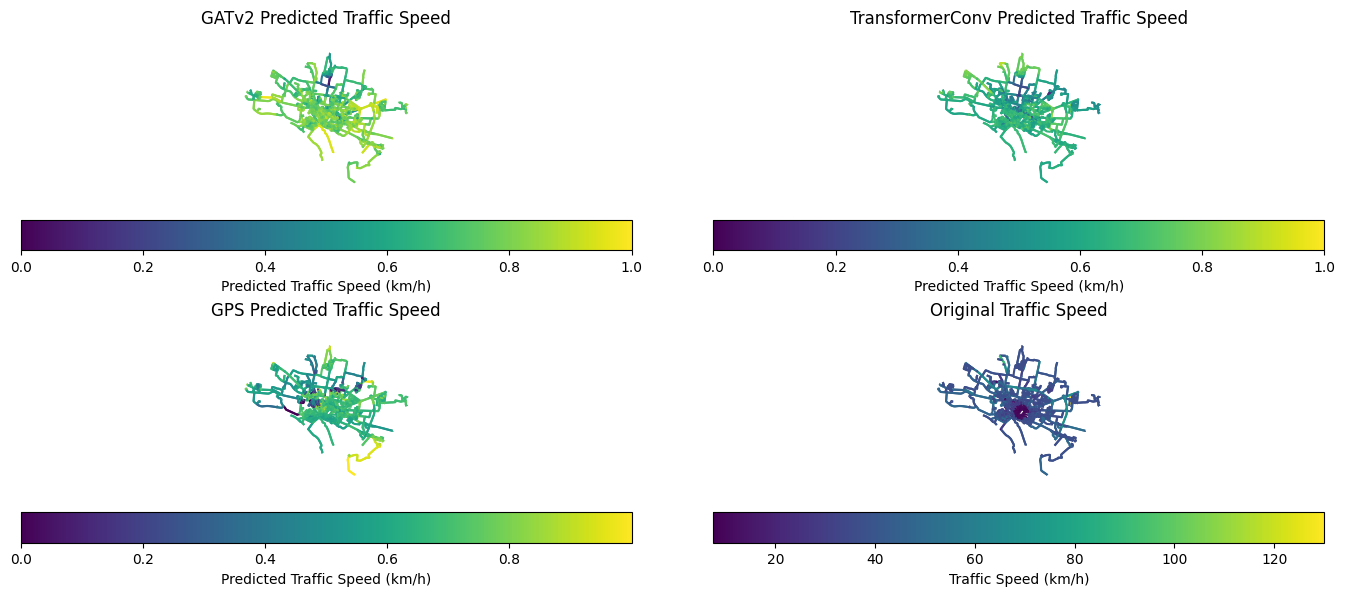

In [92]:
# compare the three models
fig, axs = plt.subplots(2, 2, figsize=(14, 6))
ax1, ax2, ax3, ax4 = axs.flatten()
# Plot the GAT predictions
edges_gnn2.plot(column='gat_predictions', ax=ax1, legend=True, cmap='viridis', legend_kwds={
    'label': "Predicted Traffic Speed (km/h)",
    'orientation': "horizontal"
})
ax1.set_title('GATv2 Predicted Traffic Speed')
ax1.set_axis_off()
# Plot the GT predictions
edges_gnn2.plot(column='gt_predictions', ax=ax2, legend=True, cmap='viridis', legend_kwds={
    'label': "Predicted Traffic Speed (km/h)",
    'orientation': "horizontal"
})
ax2.set_title('TransformerConv Predicted Traffic Speed')
ax2.set_axis_off()
# Plot the GPS predictions
edges_gnn2.plot(column='gps_predictions', ax=ax3, legend=True, cmap='viridis', legend_kwds={
    'label': "Predicted Traffic Speed (km/h)",
    'orientation': "horizontal"
})
ax3.set_title('GPS Predicted Traffic Speed')
ax3.set_axis_off()
# Plot the original traffic speed
edges_gnn2.plot(column='traffic_speed', ax=ax4, legend=True, cmap='viridis', legend_kwds={
    'label': "Traffic Speed (km/h)",
    'orientation': "horizontal"
})
ax4.set_title('Original Traffic Speed')
ax4.set_axis_off()
plt.tight_layout()
plt.show()

In [93]:
# Let's try to finetune the GPS model a bit more on the new data
# Load best model for final evaluation
model.load_state_dict(torch.load('best_CR_gps.pt'))

<All keys matched successfully>

In [94]:
# Training loop
EPOCHS = 100
best_loss = float('inf')
early_stop_counter = 0
early_stop_patience = 30
train_losses, val_losses = [], []
print(f"Starting training on {device}...")
for epoch in range(1, EPOCHS + 1):
    # Train
    train_loss = train(data2)
    train_losses.append(train_loss)
    
    # Evaluate on validation set
    val_loss = evaluate(data2, data2.val_mask)
    val_losses.append(val_loss)
    
    # Adjust learning rate
    scheduler.step(val_loss)
    
    # Early stopping check
    if val_loss < best_loss:
        best_loss = val_loss
        torch.save(model.state_dict(), 'best_gps_finetune.pt')
        early_stop_counter = 0
    else:
        early_stop_counter += 1
        
        
    
    # Print progress
    if epoch % 10 == 0:
        print(f'Epoch: {epoch:03d}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, ')
        
    # Check for early stopping
    if early_stop_counter >= early_stop_patience:
        print(f"Early stopping at epoch {epoch}")
        break

Starting training on cpu...
Epoch: 010, Train Loss: 129.3567, Val Loss: 159.0965, 
Epoch: 020, Train Loss: 118.4797, Val Loss: 128.9830, 
Epoch: 030, Train Loss: 109.0809, Val Loss: 125.6675, 
Epoch: 040, Train Loss: 105.1324, Val Loss: 122.9433, 
Epoch: 050, Train Loss: 102.6216, Val Loss: 119.2779, 
Epoch: 060, Train Loss: 101.5681, Val Loss: 115.5919, 
Epoch: 070, Train Loss: 98.7074, Val Loss: 113.5945, 
Epoch: 080, Train Loss: 101.5249, Val Loss: 110.5431, 
Epoch: 090, Train Loss: 99.4785, Val Loss: 109.4153, 
Epoch: 100, Train Loss: 94.7598, Val Loss: 108.1580, 


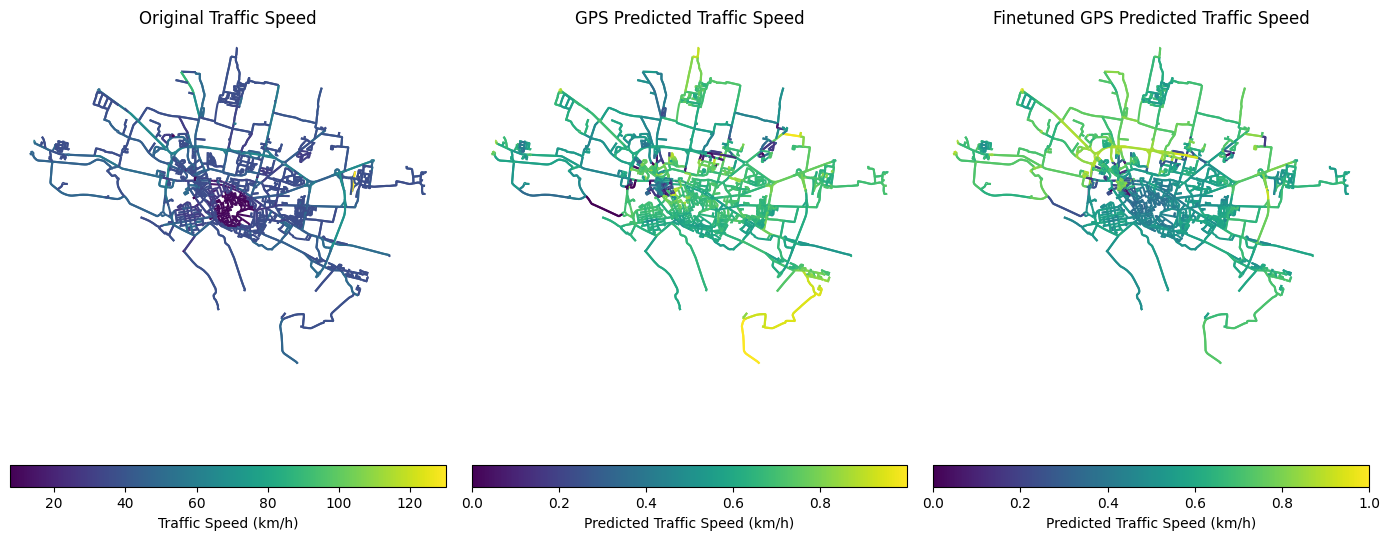

In [95]:
# Load best model for final evaluation
model.load_state_dict(torch.load('best_gps_finetune.pt'))

# Generate predictions for all nodes to compare finetuned model with the previous one
model.eval()
with torch.no_grad():
    predictions_pc = model(data2.x, data2.pe, data2.edge_index).squeeze().cpu().numpy()
# Normalize the predictions
scaler = MinMaxScaler()
predictions_pc = scaler.fit_transform(predictions_pc.reshape(-1, 1))
# Add predictions back to the geodataframe for visualization
edges_gnn2['gps_predictions_finetune'] = predictions_pc
#Compare the two models with the ground truth
fig, axs = plt.subplots(1, 3, figsize=(14, 6))
ax1, ax2, ax3 = axs.flatten()
# Plot the original traffic speed
edges_gnn2.plot(column='traffic_speed', ax=ax1, legend=True, cmap='viridis', legend_kwds={
    'label': "Traffic Speed (km/h)",
    'orientation': "horizontal"
})
ax1.set_title('Original Traffic Speed')
ax1.set_axis_off()
# Plot the GPS predictions
edges_gnn2.plot(column='gps_predictions', ax=ax2, legend=True, cmap='viridis', legend_kwds={
    'label': "Predicted Traffic Speed (km/h)",
    'orientation': "horizontal"
})
ax2.set_title('GPS Predicted Traffic Speed')
ax2.set_axis_off()
# Plot the finetuned GPS predictions
edges_gnn2.plot(column='gps_predictions_finetune', ax=ax3, legend=True, cmap='viridis', legend_kwds={
    'label': "Predicted Traffic Speed (km/h)",
    'orientation': "horizontal"
})
ax3.set_title('Finetuned GPS Predicted Traffic Speed')
ax3.set_axis_off()
plt.tight_layout()
# Save the picture
plt.savefig('Cremona_GPS_finetune.png', dpi=600, bbox_inches='tight')
plt.show()



## One step back, in order to jump forward
Let's try to implement a straight graph transformer, the performer that I used in gps

In [27]:
from torch_geometric.nn.attention import PerformerAttention
import torch.nn.functional as F

# Define hyperparameters
HIDDEN_DIM = 64
LR = 0.01
EPOCHS = 1000


class GraphPerformer(nn.Module):
    """
    A Performer-based model for graph data processing.
    """
    def __init__(
        self,
        in_channels: int,
        pe_dim: int,
        hidden_channels: int,
        heads: int,
        head_channels: int,
        dropout: float = 0.4,
        kernel = torch.nn.ReLU(),
    ):
        super().__init__()
        
        # Input embedding

        self.node_emb = Linear(in_channels, hidden_channels - pe_dim)
        self.pe_lin = Linear(20, pe_dim)
        self.pe_norm = BatchNorm1d(20)
        
        
        # Attention block with normalization
        self.norm1 = nn.LayerNorm(hidden_channels)
        self.attention = PerformerAttention(
            channels=hidden_channels,
            heads=heads,
            head_channels=head_channels,
            kernel=kernel,
            dropout=dropout
        )
        
        # Feed-forward block
        self.mlp = Sequential(
            Linear(2* hidden_channels, hidden_channels),
            ReLU(),
            Linear(hidden_channels, 1)
            
        )
    
    def forward(self, x, pe, edge_index ,mask = None):
        
        # Input embedding
        x_pe = self.pe_norm(pe)
        #print(f"x_pe: {x_pe.shape}")
        x = torch.cat((self.node_emb(x), self.pe_lin(x_pe)), 1)
        #print(f"x: {x.shape}")
        #x = self.input_proj(x)
        
        # Attention block with residual connection
        residual = x
        x = self.norm1(x)
        #print(f"x: {x.shape}")
        x = x.unsqueeze(0)
        x = residual + self.attention(x, mask=mask)
        x = x.squeeze(0)
        #print(f"x: {x.shape}")
        
        # Feed-forward block 

        src, dst = edge_index
        x = torch.cat((x[src], x[dst]), dim=1)
        x = self.mlp(x)
        
                
        return x
    
    @torch.no_grad()
    def redraw_projection_matrix(self):
        """Redraws the random projection matrix to improve approximation."""
        self.attention.redraw_projection_matrix()

# Initialise model instance
model = GraphPerformer(
    in_channels=data.x.shape[1],
    pe_dim=8,
    hidden_channels=HIDDEN_DIM,
    heads=4,
    head_channels=16,
    dropout=0.5
).to(device)
model

GraphPerformer(
  (node_emb): Linear(in_features=6, out_features=56, bias=True)
  (pe_lin): Linear(in_features=20, out_features=8, bias=True)
  (pe_norm): BatchNorm1d(20, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (attention): PerformerAttention(heads=4, head_channels=16 kernel=ReLU())
  (mlp): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=1, bias=True)
  )
)

In [28]:
print(f"data.x shape: {data.x.shape}")
print(f"data.pe shape: {data.pe.shape}")
print(f"Number of nodes: {data.x.shape[0]}")

data.x shape: torch.Size([3231, 6])
data.pe shape: torch.Size([3231, 20])
Number of nodes: 3231


In [29]:
# Define loss and optimizer
criterion = nn.MSELoss()  # Mean Squared Error for regression
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=20)
redraw_freq = 1000
# Training function
def train_performer(data):
    model.train()
    optimizer.zero_grad()
    if epoch % redraw_freq == 0:
        model.redraw_projection_matrix()
    out = model(data.x, data.pe, data.edge_index)
    pred = out[data.train_mask].squeeze()
    loss = criterion(pred , data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()

# Evaluation function
def evaluate_performer(data, mask):
    model.eval()
    with torch.no_grad():
        out = model(data.x, data.pe, data.edge_index)
        pred = out[mask].squeeze()
        true = data.y[mask]
        loss = criterion(pred, true)
    return loss.item()

In [30]:
# Training loop
best_loss = float('inf')
early_stop_counter = 0
early_stop_patience = 30
train_losses, val_losses = [], []
print(f"Starting training on {device}...")

for epoch in range(1, EPOCHS + 1):
    # Train
    train_loss = train_performer(data)
    train_losses.append(train_loss)
    
    # Evaluate on validation set
    val_loss = evaluate_performer(data, data.val_mask)
    val_losses.append(val_loss)
    
    # Adjust learning rate
    scheduler.step(val_loss)
    
    # Early stopping check
    if val_loss < best_loss:
        best_loss = val_loss
        torch.save(model.state_dict(), 'best_CR_performer.pt')
        early_stop_counter = 0
    else:
        early_stop_counter += 1
        
        
    
    # Print progress
    if epoch % 10 == 0:
        test_loss  = evaluate_performer(data, data.test_mask)
        print(f'Epoch: {epoch:03d}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, '
              f'Test Loss: {test_loss:.4f}, ')
        
    # Check for early stopping
    if early_stop_counter >= early_stop_patience:
        print(f"Early stopping at epoch {epoch}")
        break

Starting training on cpu...
Epoch: 010, Train Loss: 489.1575, Val Loss: 530.6018, Test Loss: 545.7613, 
Epoch: 020, Train Loss: 139.4172, Val Loss: 82.3068, Test Loss: 96.3787, 
Epoch: 030, Train Loss: 154.2283, Val Loss: 131.4272, Test Loss: 144.2464, 
Epoch: 040, Train Loss: 100.5547, Val Loss: 96.9963, Test Loss: 109.7822, 
Epoch: 050, Train Loss: 98.1154, Val Loss: 79.4070, Test Loss: 92.9520, 
Epoch: 060, Train Loss: 96.5916, Val Loss: 77.6098, Test Loss: 91.5841, 
Epoch: 070, Train Loss: 91.5839, Val Loss: 75.0350, Test Loss: 89.5367, 
Epoch: 080, Train Loss: 86.0234, Val Loss: 68.4672, Test Loss: 82.2952, 
Epoch: 090, Train Loss: 77.0120, Val Loss: 63.4574, Test Loss: 73.9769, 
Epoch: 100, Train Loss: 66.9381, Val Loss: 59.1004, Test Loss: 68.4958, 
Epoch: 110, Train Loss: 65.5197, Val Loss: 55.4776, Test Loss: 63.4995, 
Epoch: 120, Train Loss: 67.8860, Val Loss: 53.5559, Test Loss: 60.6103, 
Epoch: 130, Train Loss: 61.2075, Val Loss: 52.5353, Test Loss: 59.0910, 
Epoch: 140, Tr

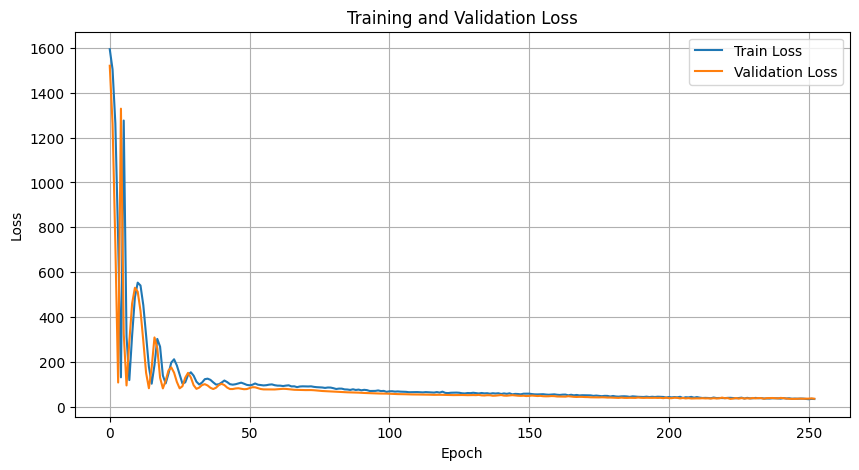

In [31]:
# Plot training and validation loss
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid()

In [32]:
# Load best model for final evaluation
model.load_state_dict(torch.load('best_CR_performer.pt'))
test_loss = evaluate_performer(data, data.test_mask)
print(f'Final Test Results - Loss: {test_loss:.4f}')

Final Test Results - Loss: 38.3266


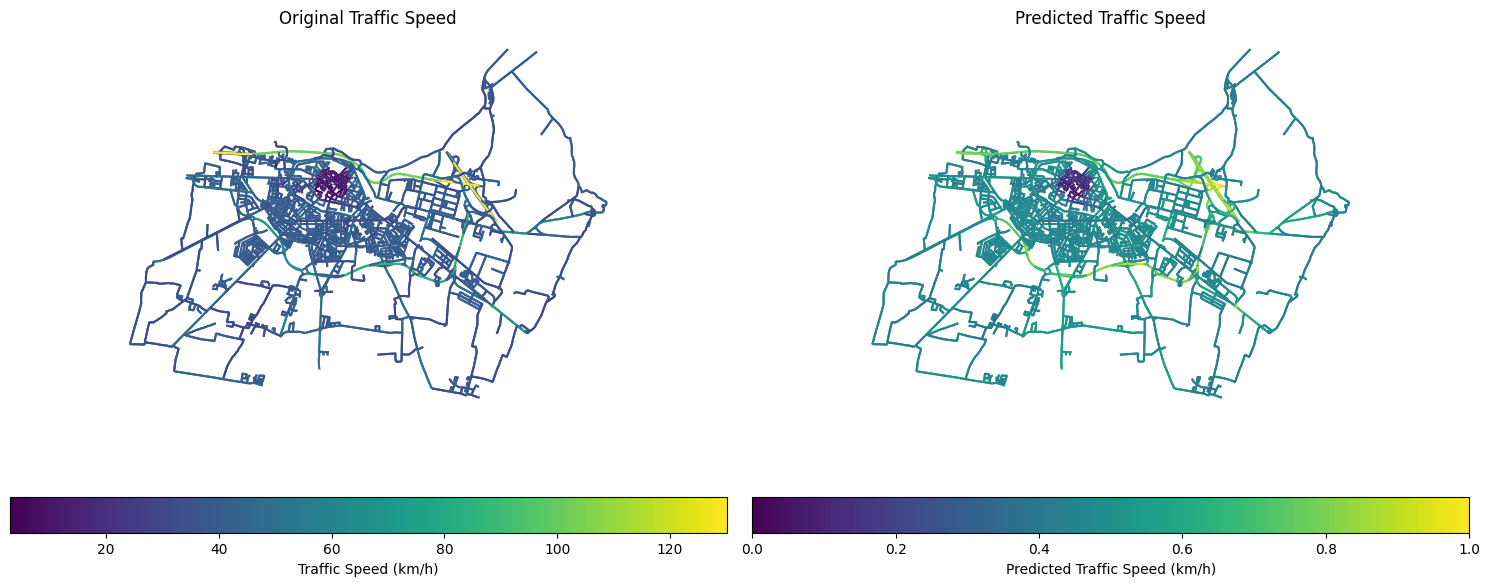

In [33]:
# Generate predictions for all nodes
model.eval()
with torch.no_grad():
    predictions = model(data.x, data.pe, data.edge_index).squeeze().cpu().numpy()
# Normalize the predictions
scaler = MinMaxScaler()
predictions = scaler.fit_transform(predictions.reshape(-1, 1))
# Add predictions back to the geodataframe for visualization
edges_gnn['performer_predictions'] = predictions
#Visualize the predictions
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
# Plot the original traffic speed
edges_gnn.plot(column='traffic_speed', ax=ax1, legend=True, cmap='viridis', legend_kwds={
    'label': "Traffic Speed (km/h)",
    'orientation': "horizontal"
})
ax1.set_title('Original Traffic Speed')
ax1.set_axis_off()
# Plot the predicted traffic speed
edges_gnn.plot(column='performer_predictions', ax=ax2, legend=True, cmap='viridis', legend_kwds={
    'label': "Predicted Traffic Speed (km/h)",
    'orientation': "horizontal"
})
ax2.set_title('Predicted Traffic Speed')
ax2.set_axis_off()
plt.tight_layout()
plt.show()


I guess the performer learns, very nice, and has no information about the graph, just a positional encoding

## Instead of Performer let's use a classical Multihead transformer



In [37]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# Define hyperparameters
HIDDEN_DIM = 64
LR = 0.01
EPOCHS = 1000


class GraphTransformer(nn.Module):
    """
    A Transformer-based model for graph data processing.
    """
    def __init__(
        self,
        in_channels: int,
        pe_dim: int,
        hidden_channels: int,
        heads: int,
        dropout: float = 0.4,
    ):
        super().__init__()
        
        # Input embedding
        self.node_emb = Linear(in_channels, hidden_channels - pe_dim)
        self.pe_lin = Linear(20, pe_dim)
        self.pe_norm = BatchNorm1d(20)


        # Attention block with normalization
        self.norm1 = nn.LayerNorm(hidden_channels)
        self.attention = nn.MultiheadAttention(
            embed_dim=hidden_channels,
            num_heads=heads,
            dropout=dropout,
            batch_first=True
        )
        
        # Feed-forward block
        self.mlp = Sequential(
            Linear(2* hidden_channels, hidden_channels),
            ReLU(),
            Linear(hidden_channels, 1)
            
        )
        
    
    def forward(self, x, pe, edge_index ,mask = None):
        
        # Input embedding
        x_pe = self.pe_norm(pe)
        x = torch.cat((self.node_emb(x), self.pe_lin(x_pe)), 1)
        
        # Attention block with residual connection
        residual = x
        x = self.norm1(x)
        
        x = x.unsqueeze(0)

        attn_mask = None

        # Apply self-attention (q,k,v are all the same in self-attention)
        attn_output, attn_weights = self.attention(
            query=x,
            key=x,
            value=x,
            attn_mask = attn_mask,
            need_weights= True
        )
        x = attn_output.squeeze(0) + residual

        # Feed-forward block
        src, dst = edge_index
        x = torch.cat((x[src], x[dst]), dim=1)  # [num_edges, 2*hidden_channels]
        x = self.mlp(x)         # [num_edges, 1]
        return x 
    
# Initialise model instance
model = GraphTransformer(
    in_channels=data.x.shape[1],
    pe_dim=8,
    hidden_channels=HIDDEN_DIM,
    heads=4,
    dropout=0.5
).to(device)
model

GraphTransformer(
  (node_emb): Linear(in_features=6, out_features=56, bias=True)
  (pe_lin): Linear(in_features=20, out_features=8, bias=True)
  (pe_norm): BatchNorm1d(20, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (attention): MultiheadAttention(
    (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
  )
  (mlp): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=1, bias=True)
  )
)

In [38]:
# Define loss and optimizer
criterion = nn.MSELoss()  
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=20)
redraw_freq = 1000
# Training function
def train_transformer(data):
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.pe, data.edge_index)
    pred = out[data.train_mask].squeeze()
    loss = criterion(pred , data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()

# Evaluation function
def evaluate_performer(data, mask):
    model.eval()
    with torch.no_grad():
        out = model(data.x, data.pe, data.edge_index)
        pred = out[mask].squeeze()
        true = data.y[mask]
        loss = criterion(pred, true)
    return loss.item()

In [39]:
# Training loop
best_loss = float('inf')
early_stop_counter = 0
early_stop_patience = 30
train_losses, val_losses = [], []
print(f"Starting training on {device}...")

for epoch in range(1, EPOCHS + 1):
    # Train
    train_loss = train_transformer(data)
    train_losses.append(train_loss)
    
    # Evaluate on validation set
    val_loss = evaluate_performer(data, data.val_mask)
    val_losses.append(val_loss)
    
    # Adjust learning rate
    scheduler.step(val_loss)
    
    # Early stopping check
    if val_loss < best_loss:
        best_loss = val_loss
        torch.save(model.state_dict(), 'best_CR_transformer.pt')
        early_stop_counter = 0
    else:
        early_stop_counter += 1
        
        
    
    # Print progress
    if epoch % 10 == 0:
        test_loss  = evaluate_performer(data, data.test_mask)
        print(f'Epoch: {epoch:03d}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, '
              f'Test Loss: {test_loss:.4f}, ')
        
    # Check for early stopping
    if early_stop_counter >= early_stop_patience:
        print(f"Early stopping at epoch {epoch}")
        break

Starting training on cpu...
Epoch: 010, Train Loss: 244.8496, Val Loss: 118.8032, Test Loss: 132.4245, 
Epoch: 020, Train Loss: 82.1336, Val Loss: 110.9319, Test Loss: 123.5859, 
Epoch: 030, Train Loss: 90.2496, Val Loss: 99.2750, Test Loss: 111.9293, 
Epoch: 040, Train Loss: 73.0636, Val Loss: 73.6858, Test Loss: 86.3188, 
Epoch: 050, Train Loss: 66.7886, Val Loss: 75.8902, Test Loss: 86.8677, 
Epoch: 060, Train Loss: 61.5429, Val Loss: 80.5083, Test Loss: 91.1257, 
Epoch: 070, Train Loss: 59.1935, Val Loss: 70.7115, Test Loss: 80.8863, 
Epoch: 080, Train Loss: 57.0780, Val Loss: 62.6471, Test Loss: 71.8195, 
Epoch: 090, Train Loss: 54.7931, Val Loss: 57.4833, Test Loss: 63.8622, 
Epoch: 100, Train Loss: 52.7961, Val Loss: 54.6916, Test Loss: 60.2969, 
Epoch: 110, Train Loss: 51.7216, Val Loss: 52.4928, Test Loss: 58.0083, 
Epoch: 120, Train Loss: 48.8278, Val Loss: 50.7636, Test Loss: 55.8555, 
Epoch: 130, Train Loss: 47.3386, Val Loss: 49.4177, Test Loss: 54.0106, 
Epoch: 140, Train

In [40]:
# Load best model for final evaluation
model.load_state_dict(torch.load('best_CR_transformer.pt'))
test_loss = evaluate_performer(data, data.test_mask)
print(f'Final Test Results - Loss: {test_loss:.4f}')

Final Test Results - Loss: 42.9250


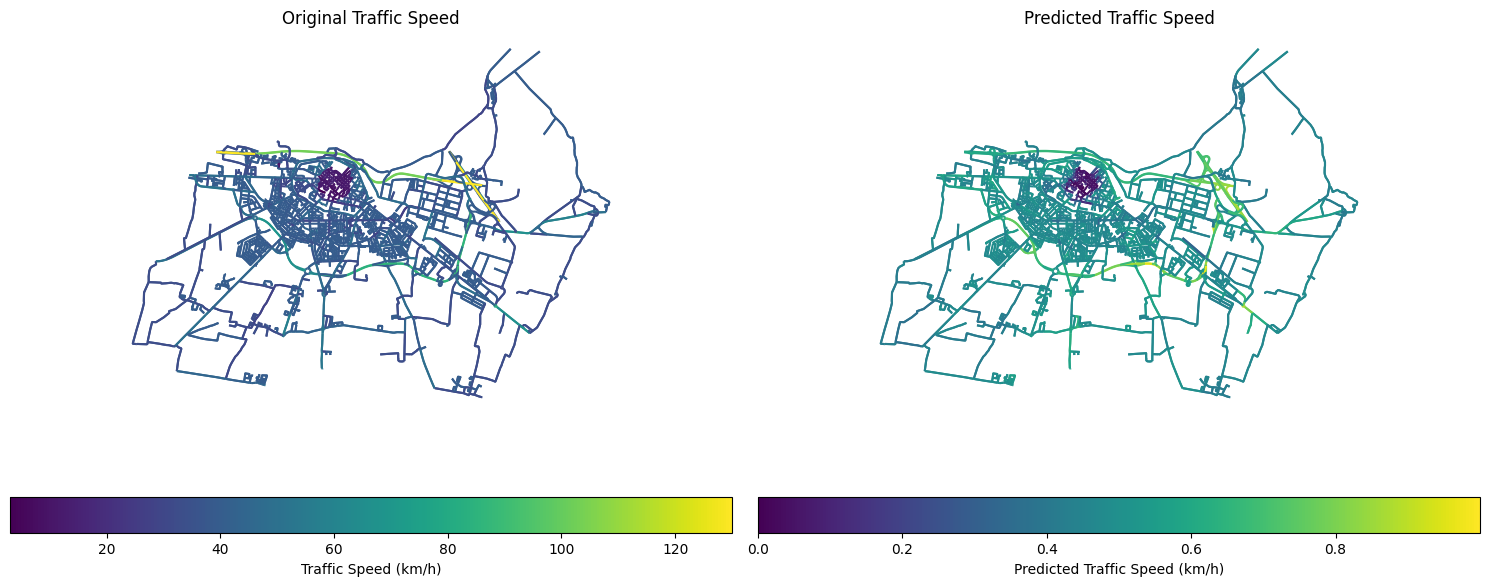

In [41]:
# Generate predictions for all nodes
model.eval()
with torch.no_grad():
    predictions = model(data.x, data.pe, data.edge_index).squeeze().cpu().numpy()
# Normalize the predictions
scaler = MinMaxScaler()
predictions = scaler.fit_transform(predictions.reshape(-1, 1))
# Add predictions back to the geodataframe for visualization
edges_gnn['transformer_predictions'] = predictions
#Visualize the predictions
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
# Plot the original traffic speed
edges_gnn.plot(column='traffic_speed', ax=ax1, legend=True, cmap='viridis', legend_kwds={
    'label': "Traffic Speed (km/h)",
    'orientation': "horizontal"
})
ax1.set_title('Original Traffic Speed')
ax1.set_axis_off()
# Plot the predicted traffic speed
edges_gnn.plot(column='transformer_predictions', ax=ax2, legend=True, cmap='viridis', legend_kwds={
    'label': "Predicted Traffic Speed (km/h)",
    'orientation': "horizontal"
})
ax2.set_title('Predicted Traffic Speed')
ax2.set_axis_off()
plt.tight_layout()
plt.show()